## Task
Develop a computer vision system that, given a reference image for each book, is able to identify such book from one picture of a shelf.

<figure>
<a href="https://ibb.co/pvLVjbM5"><img src="https://i.ibb.co/svVx9bNz/example.png" alt="example" border="0"></a>
</figure>

For each type of product displayed on the shelf, the system should compute a bounding box aligned with the book spine or cover and report:
1. Number of instances;
1. Dimension of each instance (area in pixel of the bounding box that encloses each one of them);
1. Position in the image reference system of each instance (four corners of the bounding box that enclose them);
1. Overlay of the bounding boxes on the scene images.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

#### Example of expected output
```
Book 0 - 2 instance(s) found:
  Instance 1 {top_left: (100,200), top_right: (110, 220), bottom_left: (10, 202), bottom_right: (10, 208), area: 230px}
  Instance 2 {top_left: (90,310), top_right: (95, 340), bottom_left: (24, 205), bottom_right: (23, 234), area: 205px}
Book 1 – 1 instance(s) found:
.
.
.
```

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

In [2]:
# from google.colab import drive
# drive.mount('/content/drive') 

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
# !unzip dataset.zip

In [3]:
# get models and scenes images
models_path = './dataset/models/'
scenes_path = './dataset/scenes/'
imgs_model = [os.path.join(models_path, f) for f in os.listdir(models_path)]
imgs_scene = [os.path.join(scenes_path, f) for f in os.listdir(scenes_path)]

In [47]:
def locate_book_in_scene(img_model_path:str,
                         img_scene_path:str,
                         hyp_params:dict={}):
  
  # hyper-parameters:
  min_match_count = hyp_params.get('min_match_count', 50)
  good_matches_threshold = hyp_params.get('good_matches_threshold', 0.75)
  sigma = hyp_params.get('sift_sigma', 0.5)
  mask_discount_percentage = hyp_params.get('mask_discount_percentage', 0.0)

  img_scene = cv2.imread(img_scene_path)
  img_model = cv2.imread(img_model_path)

  sift = cv2.SIFT_create(sigma=sigma)

  instances = []

  while True:

    kp_model = sift.detect(img_model)
    kp_scene = sift.detect(img_scene)

    kp_model, des_model = sift.compute(img_model, kp_model)
    kp_scene, des_scene = sift.compute(img_scene, kp_scene)

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des_model, des_scene, k=2)

    good = [m for m, n in matches if m.distance < good_matches_threshold * n.distance]

    # Corners of the model image
    h, w = img_model.shape[:2]
    pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

    if len(good) > min_match_count:
        # Building the correspondence arrays of good matches
        src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        # Using RANSAC to estimate a robust homography.
        # It returns the homography M and a mask for the discarded points.
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # Mask of discarded point used in visualization
        matches_mask = mask.ravel().tolist()

        # Corners of the model image
        h, w = img_model.shape[:2]
        h_t, w_t = img_scene.shape[:2]
        pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

        # Projecting the corners into the scene image
        dst = cv2.perspectiveTransform(pts, M)

        # Saving position and area info
        instances.append({
            "dst" : dst,
            "top_left" : (int(dst[0][0][0]), int(dst[0][0][1])),
            "bottom_left" : (int(dst[1][0][0]), int(dst[1][0][1])),
            "bottom_right" : (int(dst[2][0][0]), int(dst[2][0][1])),
            "top_right" : (int(dst[3][0][0]), int(dst[3][0][1])),
            "area": int(cv2.contourArea(dst))
        })
        # Drawing the bounding box
        img_scene = cv2.polylines(img_scene,[np.int32(dst)], True, 255, 3, cv2.LINE_AA)

        #we create a mask to avoid detecting the same object again: however, we use slightly smaller masking in order not to miss objects that are very close to each other
        #we do it in a percentage amount
        center = np.mean(dst, axis=0)
        #for every point we calculate the distance from the center and we move it closer to the center by perc%
        dst_gentle = dst.copy()
        for i in range(len(dst)):
          dst_gentle[i] = dst[i] - mask_discount_percentage * (dst[i] - center)

        img_scene = cv2.fillPoly(img_scene, [np.int32(dst_gentle)], color=(0,0,0))

        # plt.imshow(img_scene)
        # plt.show()

        # cv2.imwrite('./dataset/scenes/scene_10_2.jpg',img_scene)

    else:
        #print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
        matches_mask = None
        break

  return instances

In [5]:
models = [f'model_{i}.png' for i in range(0, 21)]
scenes = [f'scene_{i}.jpg' for i in range(0, 28)]

imgs_model = [os.path.join(models_path, f) for f in models]
imgs_scene = [os.path.join(scenes_path, f) for f in scenes]

In [6]:
import itertools

def optimize_hyperparameters(models, easy_scenes, hard_scenes, ground_truth, param_grid):

    threshold_too_many_errors = 1

    best_params = None
    best_score = -1
    best_errors = None
    
    keys, values = zip(*param_grid.items())
    
    for combo in itertools.product(*values):

        breaking = False

        print("Testing combo:", combo)
        params = dict(zip(keys, combo))
        
        all_prec, all_rec = [], []
        errors = []  # Collect mismatches for this combo



        for s_idx, scene in enumerate(easy_scenes + hard_scenes):

            scene_index = scene.split('_')[1].split('.')[0]
            scene_key = f'scene_{scene_index}'

            if scene_key not in ground_truth:
                continue

            gt_counts = ground_truth[scene_key]

            for _, model in enumerate(models):

                model_index = model.split('_')[1].split('.')[0]

                gt_count = gt_counts[int(model_index)]
                detected = locate_book_in_scene(model, scene, params)
                pred_count = len(detected)

               # print(f'for scene {scene_key} and model {model}: GT={gt_count}, Pred={pred_count}')

                # Error reporting
                if gt_count != pred_count:

                    error = {
                        'scene': scene_key,
                        'model': model,
                        'gt_count': gt_count,
                        'pred_count': pred_count,
                        'error_type': (
                            'false_positive' if gt_count == 0 and pred_count > 0 else
                            'missed_detection' if gt_count > 0 and pred_count == 0 else
                            'count_mismatch' if gt_count > 0 and pred_count > 0 else
                            'correct'  # fallback, should not happen here
                        )
                    }
                    errors.append(error)
                    print(f"  Mismatch in {scene_key} for {model}: GT={gt_count}, Pred={pred_count}")

                    #we check if the error occured for an easy scene: in that case, we throw this iteration away
                    #or if we have too many errors
                    if s_idx < len(easy_scenes) or len(errors) > threshold_too_many_errors:
                        breaking = True
                        break

                if gt_count == 0 and pred_count == 0:
                    # both say "none" -> perfect
                    precision, recall = 1.0, 1.0
                elif gt_count == 0 and pred_count > 0:
                    # false positives
                    precision, recall = 0.0, 0.0
                elif gt_count > 0 and pred_count == 0:
                    # missed all ground truth
                    precision, recall = 0.0, 0.0
                else:
                    # normal case: both > 0
                    matched = min(pred_count, gt_count)
                    precision = matched / pred_count
                    recall = matched / gt_count

                all_prec.append(precision)
                all_rec.append(recall)


            if breaking:
                print(f"Skipping rest of this combo due to easy scene mismatch or too many errors ({threshold_too_many_errors}).")
                break

        if breaking:
            continue

        if all_prec and all_rec:
            mean_prec = np.mean(all_prec)
            mean_rec = np.mean(all_rec)
            f1 = 2 * (mean_prec * mean_rec) / (mean_prec + mean_rec + 1e-10)

            print(f"  F1 = {f1:.3f}")
            if f1 > best_score:
                best_score = f1
                best_params = params
                best_errors = errors
    
    return best_params, best_score, best_errors

In [ ]:
ground_truth = {
    # gt_from_0_to_9
    "scene_0":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_1":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],  # mega dubbio sul model 18, se è 1 o 2
    "scene_2":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "scene_3":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0],
    "scene_4":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0],
    "scene_5":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_6":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "scene_7":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
    "scene_8":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_9":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],  # dubbio sul model 19, se è 2 o 4

    # gt_from_10_to_19
    "scene_10": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],
    "scene_11": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_12": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_13": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_14": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_15": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 16 and 17 but with different light or color scale
    "scene_16": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 15 and 17 but with different light or color scale
    "scene_17": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 15 and 16 but with different light or color scale
    "scene_18": [0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # NOTE: model_11 instances are 2 (one ruined, considered 1); model_12 instances are 3 (differences, considered 1)
    "scene_19": [0, 0, 0, 0, 0, 0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

    # gt
    "scene_20": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_21": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_22": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_23": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_24": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_25": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_26": [2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_27": [0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # supersus
    "scene_28": [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}

easy_scenes_keys = ["scene_0", "scene_8", "scene_11", "scene_12", "scene_13", "scene_14", "scene_20", "scene_21", "scene_22", "scene_24", "scene_25"]
impossible_scene_keys = ["scene_9", "scene_10", "scene_15", "scene_16", "scene_17", "scene_18", "scene_27"]
hard_scenes_keys = [k for k in ground_truth.keys() if k not in easy_scenes_keys and k not in impossible_scene_keys]
easy_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in easy_scenes_keys]
hard_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in hard_scenes_keys]
impossible_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in impossible_scene_keys]

# param_grid = {
#     "sigma": [0.5],
#     "min_match_count": [50],
#     "good_matches_threshold": [0.75],
#     "mask_discount_percentage": [0.1]  # New parameter to avoid re-detecting the same object
# }

param_grid = {
    "sigma": [0.5, 0.6],
    "min_match_count": [40, 45, 50],
    "good_matches_threshold": [0.72, 0.75, 0.78],
    "mask_discount_percentage": [0.08, 0.12, 0.15]  # New parameter to avoid re-detecting the same object
}

# The total number of combinations is:
total_combinations = len(param_grid["sigma"]) * len(param_grid["min_match_count"]) * len(param_grid["good_matches_threshold"])
print("Total number of combinations:", total_combinations)

best_params, best_score, best_errors = optimize_hyperparameters(imgs_model, easy_scene_paths, hard_scene_paths + impossible_scene_paths, ground_truth, param_grid)

print("Best parameters:", best_params)
print("Best F1 score:", best_score)
print("The model with the best parameters did these mistakes:")

# Print a summary of errors in a readable way
if best_errors:
    print("\nMismatches (scene, model, gt_count, pred_count, error_type):")
    for err in best_errors:
        print(f"Scene: {err['scene']}, Model: {err['model']}, GT: {err['gt_count']}, Pred: {err['pred_count']}, Type: {err['error_type']}")
else:
    print("No mismatches found!")

Scene 0:
Scene 8:
Scene 11:
Scene 12:
Scene 13:
Scene 14:
Scene 20:
Scene 21:
Scene 22:
Scene 24:
Scene 25:
expected 0 instance(s) of book 4
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (108, 295), 'top_right': (123, 250), 'bottom_left': (124, 243), 'bottom_right': (120, 251), 'area': 20}


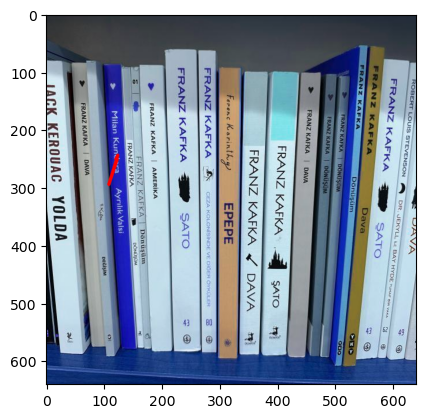

Scene 1:
expected 0 instance(s) of book 4
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (14, 299), 'top_right': (13, 300), 'bottom_left': (13, 300), 'bottom_right': (14, 299), 'area': 0}
expected 2 instance(s) of book 18
	Book 18 - 2 instance(s) found:
		Instance 1 {'top_left': (441, 41), 'top_right': (490, 42), 'bottom_left': (441, 520), 'bottom_right': (490, 520), 'area': 23190}
		Instance 2 {'top_left': (489, 39), 'top_right': (536, 41), 'bottom_left': (482, 518), 'bottom_right': (530, 518), 'area': 22581}


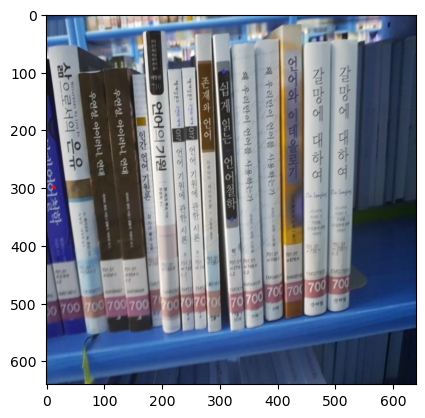

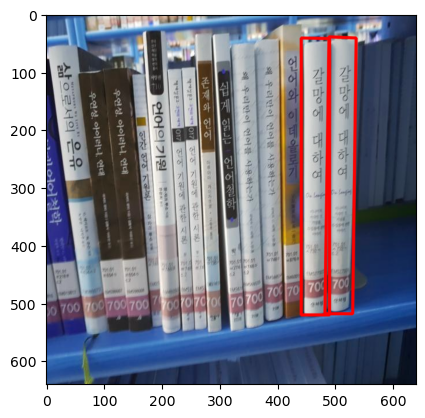

Scene 2:
expected 1 instance(s) of book 17
	Book 17 - 1 instance(s) found:
		Instance 1 {'top_left': (283, 25), 'top_right': (318, 25), 'bottom_left': (283, 503), 'bottom_right': (318, 503), 'area': 16450}


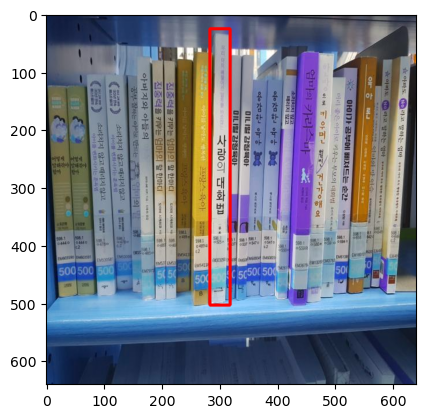

Scene 3:
expected 2 instance(s) of book 16
	Book 16 - 2 instance(s) found:
		Instance 1 {'top_left': (377, 209), 'top_right': (425, 209), 'bottom_left': (377, 542), 'bottom_right': (425, 542), 'area': 15913}
		Instance 2 {'top_left': (425, 210), 'top_right': (474, 209), 'bottom_left': (418, 550), 'bottom_right': (467, 546), 'area': 16689}


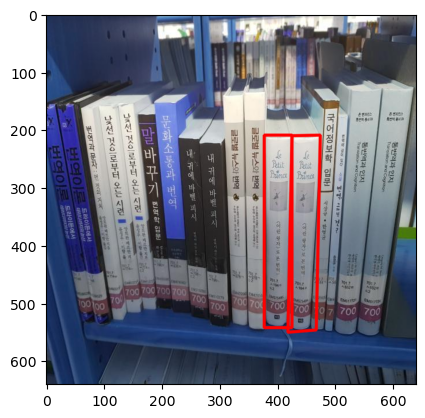

Scene 4:
expected 2 instance(s) of book 14
	Book 14 - 2 instance(s) found:
		Instance 1 {'top_left': (92, 1), 'top_right': (135, 1), 'bottom_left': (92, 617), 'bottom_right': (135, 617), 'area': 26402}
		Instance 2 {'top_left': (55, -3), 'top_right': (98, -3), 'bottom_left': (59, 618), 'bottom_right': (102, 619), 'area': 26841}
expected 2 instance(s) of book 15
	Book 15 - 2 instance(s) found:
		Instance 1 {'top_left': (226, 48), 'top_right': (267, 48), 'bottom_left': (226, 608), 'bottom_right': (267, 608), 'area': 22991}
		Instance 2 {'top_left': (191, 43), 'top_right': (234, 44), 'bottom_left': (196, 608), 'bottom_right': (238, 605), 'area': 23621}


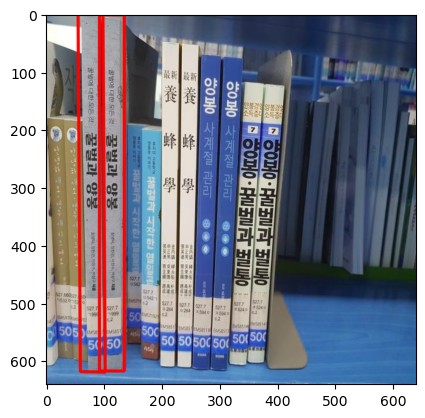

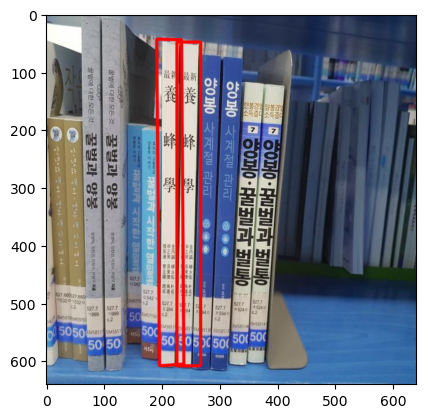

Scene 5:
expected 1 instance(s) of book 13
	Book 13 - 1 instance(s) found:
		Instance 1 {'top_left': (102, 70), 'top_right': (145, 69), 'bottom_left': (102, 572), 'bottom_right': (145, 572), 'area': 21632}


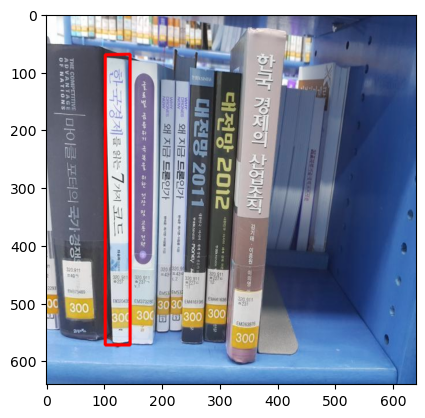

Scene 6:
Scene 7:
expected 2 instance(s) of book 20
	Book 20 - 2 instance(s) found:
		Instance 1 {'top_left': (236, 173), 'top_right': (289, 173), 'bottom_left': (235, 555), 'bottom_right': (289, 555), 'area': 20447}
		Instance 2 {'top_left': (279, 171), 'top_right': (334, 170), 'bottom_left': (276, 559), 'bottom_right': (330, 562), 'area': 21132}


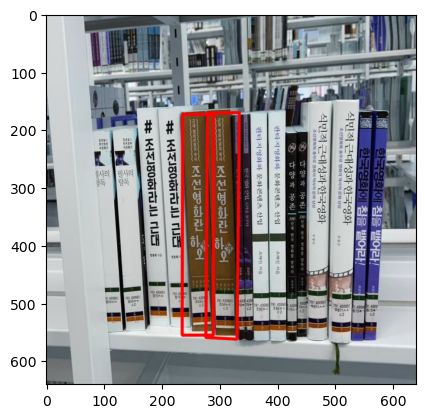

Scene 19:
expected 3 instance(s) of book 6
	Book 6 - 3 instance(s) found:
		Instance 1 {'top_left': (384, 32), 'top_right': (410, 32), 'bottom_left': (385, 579), 'bottom_right': (411, 579), 'area': 14247}
		Instance 2 {'top_left': (439, 23), 'top_right': (464, 25), 'bottom_left': (438, 575), 'bottom_right': (463, 575), 'area': 13600}
		Instance 3 {'top_left': (412, 29), 'top_right': (437, 29), 'bottom_left': (409, 577), 'bottom_right': (434, 576), 'area': 13724}
expected 2 instance(s) of book 7
	Book 7 - 2 instance(s) found:
		Instance 1 {'top_left': (497, 40), 'top_right': (533, 40), 'bottom_left': (497, 587), 'bottom_right': (533, 587), 'area': 19633}
		Instance 2 {'top_left': (459, 44), 'top_right': (493, 42), 'bottom_left': (460, 580), 'bottom_right': (495, 584), 'area': 18639}


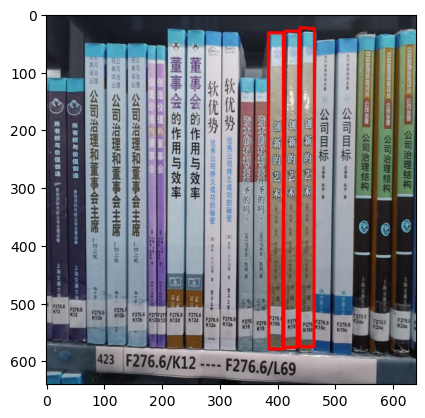

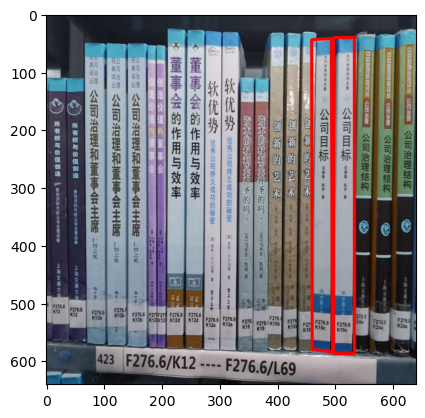

Scene 23:
expected 1 instance(s) of book 5
	Book 5 - 1 instance(s) found:
		Instance 1 {'top_left': (342, 149), 'top_right': (391, 149), 'bottom_left': (342, 571), 'bottom_right': (391, 571), 'area': 20620}


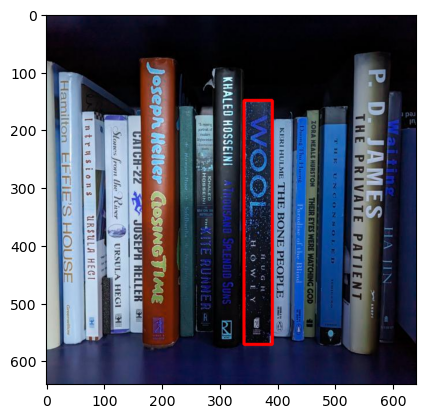

Scene 26:
expected 2 instance(s) of book 0
	Book 0 - 2 instance(s) found:
		Instance 1 {'top_left': (210, 180), 'top_right': (243, 180), 'bottom_left': (210, 567), 'bottom_right': (243, 567), 'area': 13081}
		Instance 2 {'top_left': (169, 181), 'top_right': (203, 183), 'bottom_left': (175, 573), 'bottom_right': (209, 569), 'area': 13282}
expected 1 instance(s) of book 4
	Book 4 - 4 instance(s) found:
		Instance 1 {'top_left': (248, 183), 'top_right': (432, 183), 'bottom_left': (248, 526), 'bottom_right': (432, 526), 'area': 63034}
		Instance 2 {'top_left': (255, 191), 'top_right': (432, 192), 'bottom_left': (455, 1), 'bottom_right': (113, 42), 'area': 15337}
		Instance 3 {'top_left': (174, 543), 'top_right': (175, 545), 'bottom_left': (178, 552), 'bottom_right': (176, 541), 'area': 10}
		Instance 4 {'top_left': (29, 524), 'top_right': (45, 501), 'bottom_left': (47, 496), 'bottom_right': (24, 505), 'area': 28}


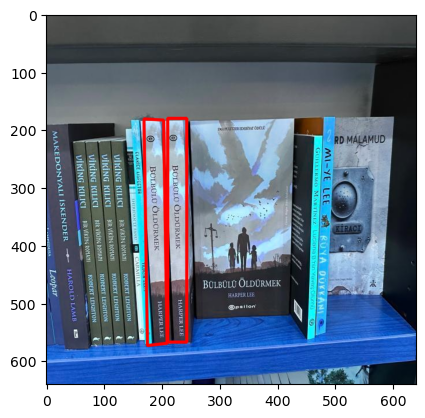

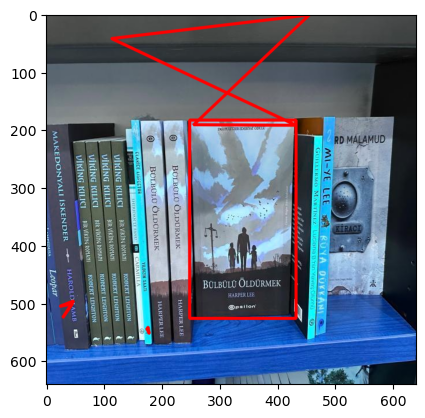

Scene 28:
expected 2 instance(s) of book 1
	Book 1 - 2 instance(s) found:
		Instance 1 {'top_left': (206, 248), 'top_right': (235, 249), 'bottom_left': (207, 554), 'bottom_right': (235, 554), 'area': 8712}
		Instance 2 {'top_left': (230, 221), 'top_right': (258, 216), 'bottom_left': (244, 532), 'bottom_right': (265, 540), 'area': 7763}


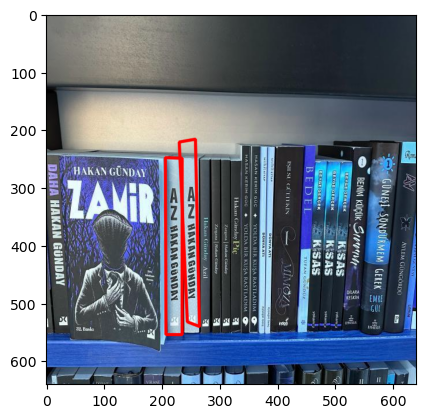

Scene 9:
expected 4 instance(s) of book 19
	Book 19 - 2 instance(s) found:
		Instance 1 {'top_left': (438, 328), 'top_right': (438, 356), 'bottom_left': (137, 339), 'bottom_right': (138, 366), 'area': 8232}
		Instance 2 {'top_left': (441, 382), 'top_right': (442, 410), 'bottom_left': (135, 392), 'bottom_right': (145, 420), 'area': 8479}


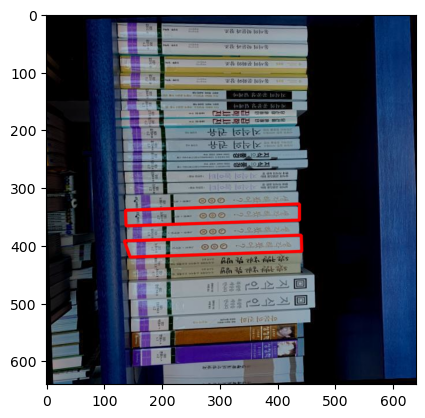

Scene 10:
expected 4 instance(s) of book 19
	Book 19 - 2 instance(s) found:
		Instance 1 {'top_left': (332, 203), 'top_right': (359, 203), 'bottom_left': (331, 503), 'bottom_right': (359, 503), 'area': 8353}
		Instance 2 {'top_left': (386, 211), 'top_right': (414, 194), 'bottom_left': (385, 515), 'bottom_right': (417, 551), 'area': 10017}


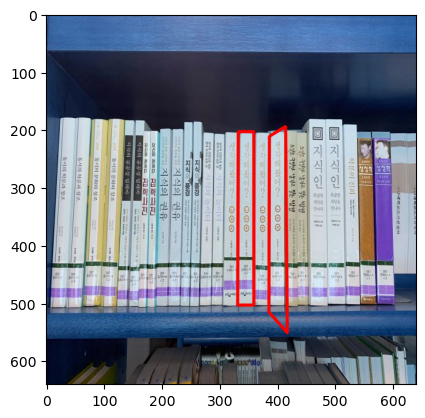

Scene 15:
expected 0 instance(s) of book 4
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (390, 205), 'top_right': (348, 177), 'bottom_left': (288, 145), 'bottom_right': (421, 243), 'area': 651}
expected 2 instance(s) of book 11
	Book 11 - 1 instance(s) found:
		Instance 1 {'top_left': (257, 187), 'top_right': (298, 187), 'bottom_left': (251, 534), 'bottom_right': (292, 536), 'area': 14244}
expected 3 instance(s) of book 12
	Book 12 - 1 instance(s) found:
		Instance 1 {'top_left': (500, 214), 'top_right': (528, 215), 'bottom_left': (494, 527), 'bottom_right': (523, 527), 'area': 8828}


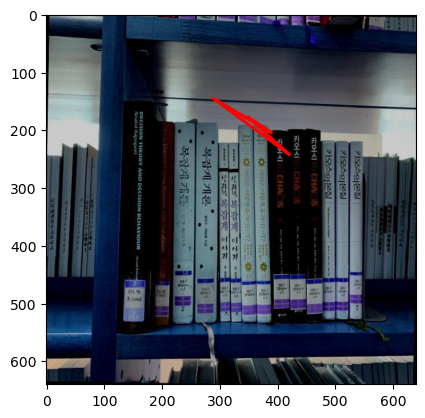

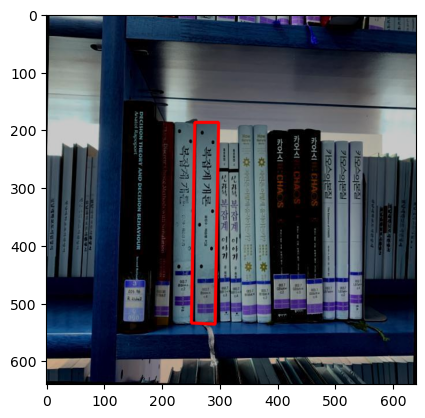

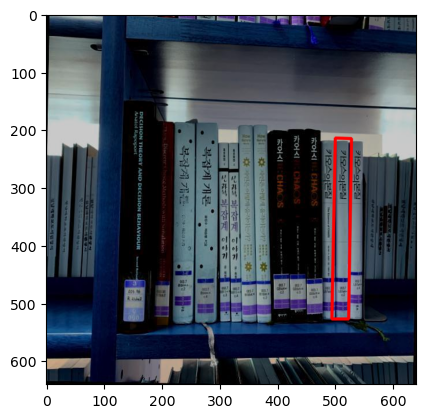

Scene 16:
expected 0 instance(s) of book 4
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (504, 147), 'top_right': (94, 192), 'bottom_left': (541, 187), 'bottom_right': (831, -1), 'area': 32503}
expected 2 instance(s) of book 11
	Book 11 - 1 instance(s) found:
		Instance 1 {'top_left': (258, 187), 'top_right': (298, 188), 'bottom_left': (251, 534), 'bottom_right': (292, 537), 'area': 14104}
expected 3 instance(s) of book 12
	Book 12 - 1 instance(s) found:
		Instance 1 {'top_left': (500, 214), 'top_right': (528, 215), 'bottom_left': (495, 527), 'bottom_right': (523, 527), 'area': 8773}


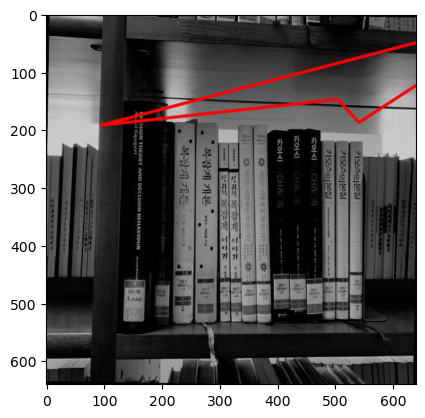

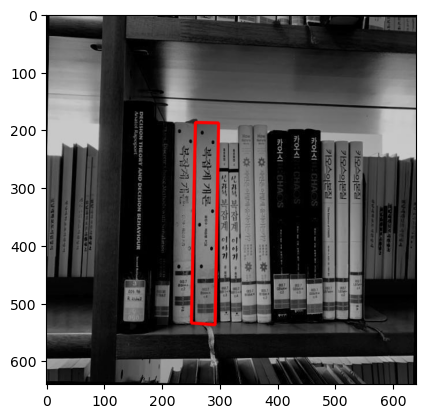

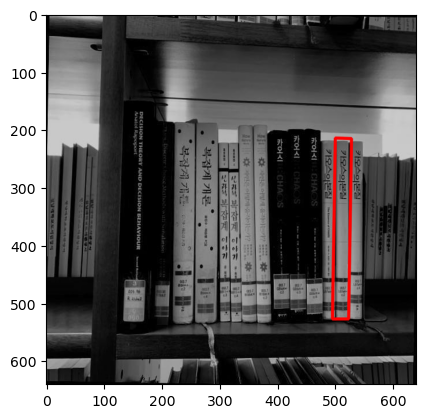

Scene 17:
expected 2 instance(s) of book 11
	Book 11 - 1 instance(s) found:
		Instance 1 {'top_left': (254, 187), 'top_right': (295, 187), 'bottom_left': (254, 535), 'bottom_right': (295, 535), 'area': 14340}
expected 3 instance(s) of book 12
	Book 12 - 2 instance(s) found:
		Instance 1 {'top_left': (497, 211), 'top_right': (526, 210), 'bottom_left': (497, 523), 'bottom_right': (526, 523), 'area': 9026}
		Instance 2 {'top_left': (522, 211), 'top_right': (551, 212), 'bottom_left': (521, 535), 'bottom_right': (551, 530), 'area': 9482}


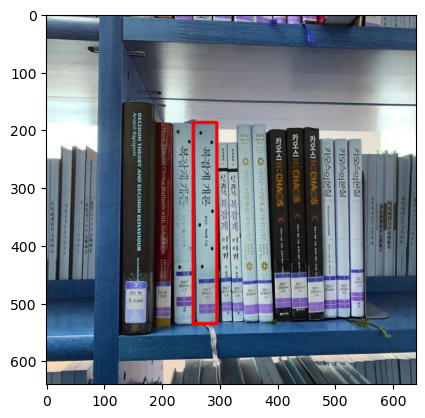

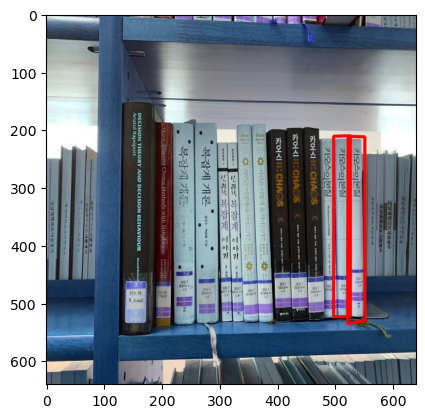

Scene 18:
expected 2 instance(s) of book 8
	Book 8 - 3 instance(s) found:
		Instance 1 {'top_left': (291, 130), 'top_right': (318, 131), 'bottom_left': (291, 587), 'bottom_right': (318, 586), 'area': 12336}
		Instance 2 {'top_left': (266, 132), 'top_right': (293, 125), 'bottom_left': (264, 580), 'bottom_right': (291, 594), 'area': 12318}
		Instance 3 {'top_left': (314, 133), 'top_right': (342, 133), 'bottom_left': (316, 586), 'bottom_right': (344, 588), 'area': 12547}
expected 1 instance(s) of book 9
	Book 9 - 3 instance(s) found:
		Instance 1 {'top_left': (315, 130), 'top_right': (342, 130), 'bottom_left': (315, 586), 'bottom_right': (342, 586), 'area': 12190}
		Instance 2 {'top_left': (267, 125), 'top_right': (294, 125), 'bottom_left': (263, 583), 'bottom_right': (289, 584), 'area': 12093}
		Instance 3 {'top_left': (292, 128), 'top_right': (317, 128), 'bottom_left': (291, 584), 'bottom_right': (315, 586), 'area': 11355}
expected 3 instance(s) of book 10
	Book 10 - 3 instance(s) found

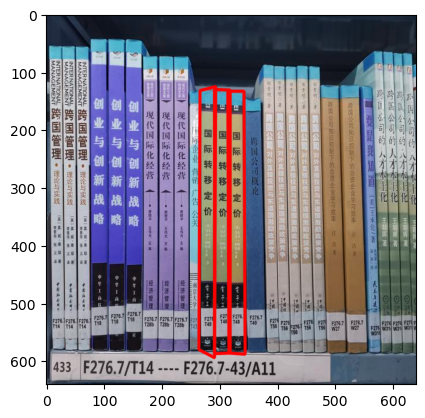

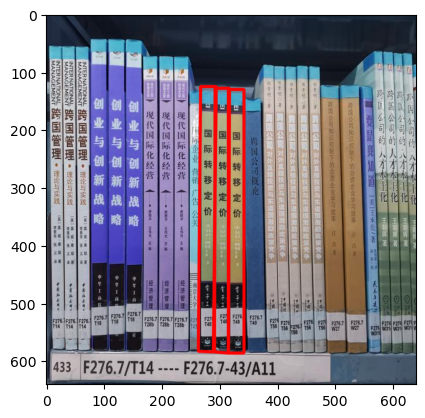

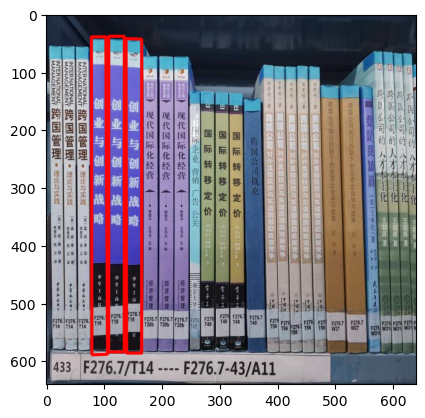

Scene 27:
expected 2 instance(s) of book 2
	Book 2 - 6 instance(s) found:
		Instance 1 {'top_left': (257, 145), 'top_right': (302, 146), 'bottom_left': (257, 563), 'bottom_right': (302, 563), 'area': 18598}
		Instance 2 {'top_left': (306, 103), 'top_right': (368, 90), 'bottom_left': (298, 578), 'bottom_right': (354, 589), 'area': 28746}
		Instance 3 {'top_left': (368, 145), 'top_right': (413, 138), 'bottom_left': (355, 582), 'bottom_right': (400, 573), 'area': 19379}
		Instance 4 {'top_left': (420, 152), 'top_right': (467, 135), 'bottom_left': (401, 555), 'bottom_right': (446, 567), 'area': 19142}
		Instance 5 {'top_left': (528, 224), 'top_right': (562, 227), 'bottom_left': (484, 581), 'bottom_right': (548, 574), 'area': 16964}
		Instance 6 {'top_left': (484, 256), 'top_right': (517, 258), 'bottom_left': (434, 604), 'bottom_right': (507, 599), 'area': 18284}
expected 2 instance(s) of book 3
	Book 3 - 5 instance(s) found:
		Instance 1 {'top_left': (416, 142), 'top_right': (466, 143), 'b

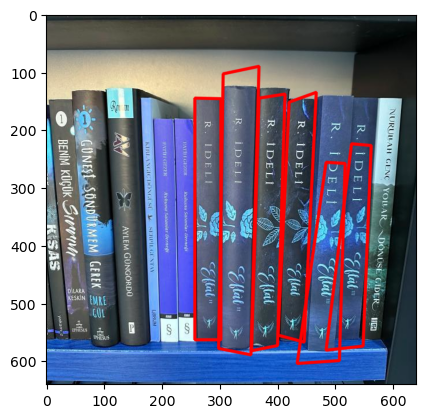

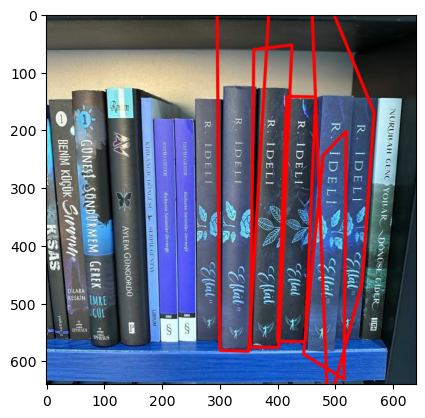

In [48]:
params = {'min_match_count': 42, 'good_matches_threshold': 0.75, 'sift_sigma': 0.5, 'mask_discount_percentage': 0.1}

for i, s in enumerate(easy_scene_paths + hard_scene_paths + impossible_scene_paths):
  
  scene_index = s.split('_')[1].split('.')[0]
  print(f"Scene {scene_index}:")

  gt_counts = ground_truth[f'scene_{scene_index}']

  books = []

  for j, m in enumerate(imgs_model):

    book_index = m.split('_')[1].split('.')[0]

    instances = locate_book_in_scene(m, s, params)

    expected_count = gt_counts[int(book_index)]



    if instances:

      print(f'expected {expected_count} instance(s) of book {book_index}')

      print(f"\tBook {book_index} - {len(instances)} instance(s) found:")



      books.append({
        "num" : j,
        "instances" : instances
      })

      for k, instance in enumerate(instances):

        printing_instance = {}
        printing_instance["top_left"] = instance["top_left"]
        printing_instance["top_right"] = instance["top_right"]
        printing_instance["bottom_left"] = instance["bottom_left"]
        printing_instance["bottom_right"] = instance["bottom_right"]
        printing_instance["area"] = instance["area"]

        print(f"\t\tInstance {k+1} {printing_instance}")

  # Plot the scene with the bounding box
  for book in books:

    img_scene = cv2.imread(s)

    for instance in book["instances"]:

      img_scene = cv2.polylines(img_scene,[np.int32(instance["dst"])], True, 255, 3, cv2.LINE_AA)

    plt.imshow(img_scene)
    plt.show()